In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("loan_approval_dataset.csv")
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
df.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.columns = df.columns.str.strip() #used to fix spaces in strings

In [7]:
df["education"] = df["education"].str.strip()
df["self_employed"] = df["self_employed"].str.strip()
df["loan_status"] = df["loan_status"].str.strip()

In [8]:
df["education"] = df["education"].map({"Graduate": 1, "Not Graduate": 0})
df["self_employed"] = df["self_employed"].map({"Yes": 1, "No": 0})
df["loan_status"] = df["loan_status"].map({"Approved": 1, "Rejected": 0})

In [9]:
df.columns

Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [10]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1
1,2,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0
2,3,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0
3,4,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0
4,5,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0


In [11]:
#feature separation
x = df.drop(["loan_id", "loan_status"], axis=1)
y = df["loan_status"]

In [12]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(3415, 11)
(854, 11)
(3415,)
(854,)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [14]:
model = LogisticRegression()
model.fit(x_train, y_train)

LogisticRegression()

In [15]:
y_pred = model.predict(x_test)
print(x_test,"\n", y_pred[:5])

[[ 1.51250774  0.99736803 -1.01504731 ...  1.15447134  0.05627784
   0.72735662]
 [-0.25599737  0.99736803 -1.01504731 ...  1.04007205  0.28522978
   0.54176071]
 [ 0.33350433  0.99736803 -1.01504731 ...  2.57302245  1.45179448
   0.51082806]
 ...
 [ 1.51250774 -1.00263891  0.98517575 ...  0.49095549 -0.37982112
   0.88201987]
 [ 0.92300603 -1.00263891 -1.01504731 ... -0.83607619 -1.0121646
  -1.09766982]
 [-0.84549907 -1.00263891 -1.01504731 ...  0.14775765 -0.59787059
  -0.97393921]] 
 [0 1 0 1 1]


In [16]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.905152224824356


In [17]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test, y_pred))

[[275  43]
 [ 38 498]]


In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.88      0.86      0.87       318
           1       0.92      0.93      0.92       536

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854



In [40]:
new_applicant = [[
    2,          # no_of_dependents
    1,          # education
    0,          # self_employed
    1200000,    # income_annum
    400000,     # loan_amount
    15,         # loan_term
    810,        # cibil_score
    5000000,    # residential_assets_value
    1000000,    # commercial_assets_value
    3000000,    # luxury_assets_value
    800000      # bank_asset_value
]]

new_applicant = scaler.transform(new_applicant)
predicted = model.predict(new_applicant)
if predicted[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")

Loan Approved


C:\Users\Hp\anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [44]:
print(model.predict_proba(x_test)[:5])

[[0.96692868 0.03307132]
 [0.15672756 0.84327244]
 [0.974874   0.025126  ]
 [0.03835549 0.96164451]
 [0.01085407 0.98914593]]


In [48]:
# In case of [0.50, 0.50]
# By default, scikit-learn predicts class 1 (Approved) 
# when the probability is ≥ 0.5. In practice, getting 
# exactly 0.50 is extremely rare because of floating-point 
# values, but the default decision threshold is 0.5.

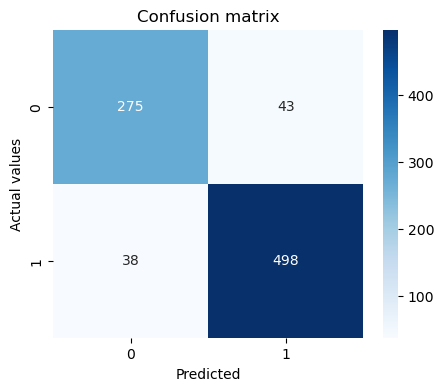

In [50]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual values")
plt.title("Confusion matrix")
plt.show()

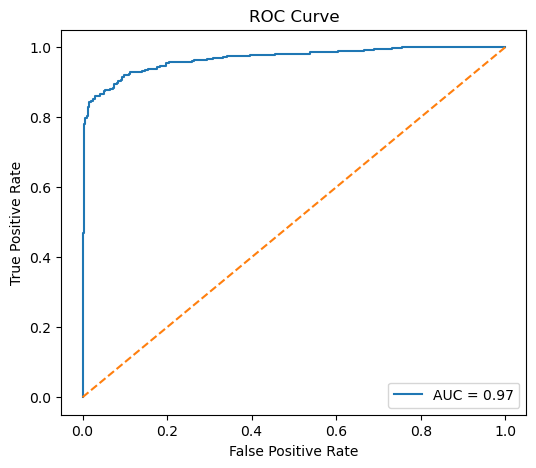

In [58]:
from sklearn.metrics import roc_curve, roc_auc_score

y_prob = model.predict_proba(x_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

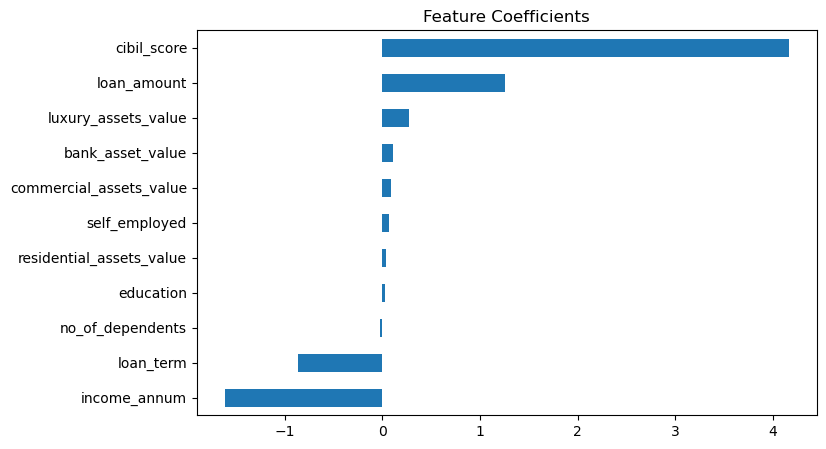

In [62]:
coef = pd.Series(model.coef_[0], index=x.columns)

coef.sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Feature Coefficients")
plt.show()

In [64]:
import joblib

joblib.dump(model, "loan_approval_model.pkl")
joblib.dump(scaler, "scaler.pkl") 

['scaler.pkl']